In [11]:
import numpy as np
import pandas as pd
import joblib
import os
from sklearn.metrics import r2_score, mean_squared_error

# -----------------------------
# Configuración
# -----------------------------
models = ["ridge", "rf", "mlp", "xgb"]  # Incluye todos los modelos disponibles

# -----------------------------
# Cargar datos test
# -----------------------------
X_test = np.load('../outputs/X_test.npy')
y_test = np.load('../outputs/y_test.npy')
df_real = pd.read_csv("../data/processed_dataset.csv")  # Mantener 'seq' original

# -----------------------------
# Evaluar modelos
# -----------------------------
results = []
df_preds = pd.DataFrame()
df_preds["seq"] = df_real["seq"][:len(X_test)]  # asegurar match de tamaño

for name in models:
    print(f"Evaluando {name}...")
    
    model_path = f'../outputs/model_{name}.pkl'
    if not os.path.exists(model_path):
        print(f"⚠️ Modelo {name} no encontrado en {model_path}, se salta.")
        continue
    
    
    model = joblib.load(model_path)
    preds = model.predict(X_test)
    
    r2 = r2_score(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    
    results.append({
        "model": name,
        "R2": r2,
        "RMSE": rmse
    })
    
    df_preds[f"{name}_PTM"] = preds[:,0]
    df_preds[f"{name}_IPTM"] = preds[:,1]

# -----------------------------
# Predicción promedio de todos los modelos
# -----------------------------
ptm_cols = [col for col in df_preds.columns if "_PTM" in col]
iptm_cols = [col for col in df_preds.columns if "_IPTM" in col]

df_preds["PTM_pred"] = df_preds[ptm_cols].mean(axis=1)
df_preds["IPTM_pred"] = df_preds[iptm_cols].mean(axis=1)

# -----------------------------
# Guardar predicciones y métricas
# -----------------------------
os.makedirs("../outputs", exist_ok=True)
df_preds.to_csv('../outputs/predictions_all_models.csv', index=False)
pd.DataFrame(results).to_csv('../outputs/model_metrics.csv', index=False)

print("\nEvaluación completada. Predicciones guardadas en '../outputs/predictions_all_models.csv'")
print(df_preds.head())

print("\nProceso finalizado.")  

Evaluando ridge...
Evaluando rf...
Evaluando mlp...
Evaluando xgb...

Evaluación completada. Predicciones guardadas en '../outputs/predictions_all_models.csv'
                                                 seq  ridge_PTM  ridge_IPTM  \
0  GYPKAEVIWTSSDHQVLSGKTTTTNSKREEKLFNVTSTLRINTTTN...   0.728508    0.216338   
1  GYPKAEVIWTSSDHQVLSGKTTTTNSKREEKLFNVTSTLRINTTTN...   0.725126    0.201112   
2  GYPKAEVIWTSSDHQVLSGKTTTTNSKREEKLFNVTSTLRINTTTN...   0.738307    0.237314   
3  GYPKAEVIWTSSDHQVLSGKTTTTNSKREEKLFNVTSTLRINTTTN...   0.726664    0.213103   
4  GYPKAEVIWTSSDHQVLSGKTTTTNSKREEKLFNVTSTLRINTTTN...   0.666207    0.167557   

     rf_PTM   rf_IPTM   mlp_PTM  mlp_IPTM   xgb_PTM  xgb_IPTM  PTM_pred  \
0  0.721145  0.180727  0.724597  0.233431  0.723307  0.197923  0.724389   
1  0.721621  0.190666  0.719645  0.177232  0.717767  0.182208  0.721040   
2  0.725408  0.175278  0.729042  0.221455  0.724251  0.178863  0.729252   
3  0.716715  0.182976  0.726821  0.288137  0.718220  0.193129  0.7

In [12]:
import pandas as pd

df = pd.read_csv("../outputs/predictions_all_models.csv")
df.head()

,seq,ridge_PTM,ridge_IPTM,rf_PTM,rf_IPTM,mlp_PTM,mlp_IPTM,xgb_PTM,xgb_IPTM,PTM_pred,IPTM_pred
0,GYPKAEVIWTSSDHQVLSGKTTTTNSKREEKLFNVTSTLRINTTTN...,0.728508,0.216338,0.721145,0.180727,0.724597,0.233431,0.723307,0.197923,0.724389,0.207105
1,GYPKAEVIWTSSDHQVLSGKTTTTNSKREEKLFNVTSTLRINTTTN...,0.725126,0.201112,0.721621,0.190666,0.719645,0.177232,0.717766,0.182208,0.721040,0.187804
2,GYPKAEVIWTSSDHQVLSGKTTTTNSKREEKLFNVTSTLRINTTTN...,0.738307,0.237314,0.725408,0.175278,0.729042,0.221455,0.724251,0.178863,0.729252,0.203228
3,GYPKAEVIWTSSDHQVLSGKTTTTNSKREEKLFNVTSTLRINTTTN...,0.726664,0.213103,0.716715,0.182976,0.726821,0.288137,0.718220,0.193129,0.722105,0.219336
4,GYPKAEVIWTSSDHQVLSGKTTTTNSKREEKLFNVTSTLRINTTTN...,0.666207,0.167557,0.681427,0.219852,0.667463,0.183321,0.679370,0.223061,0.673617,0.198448


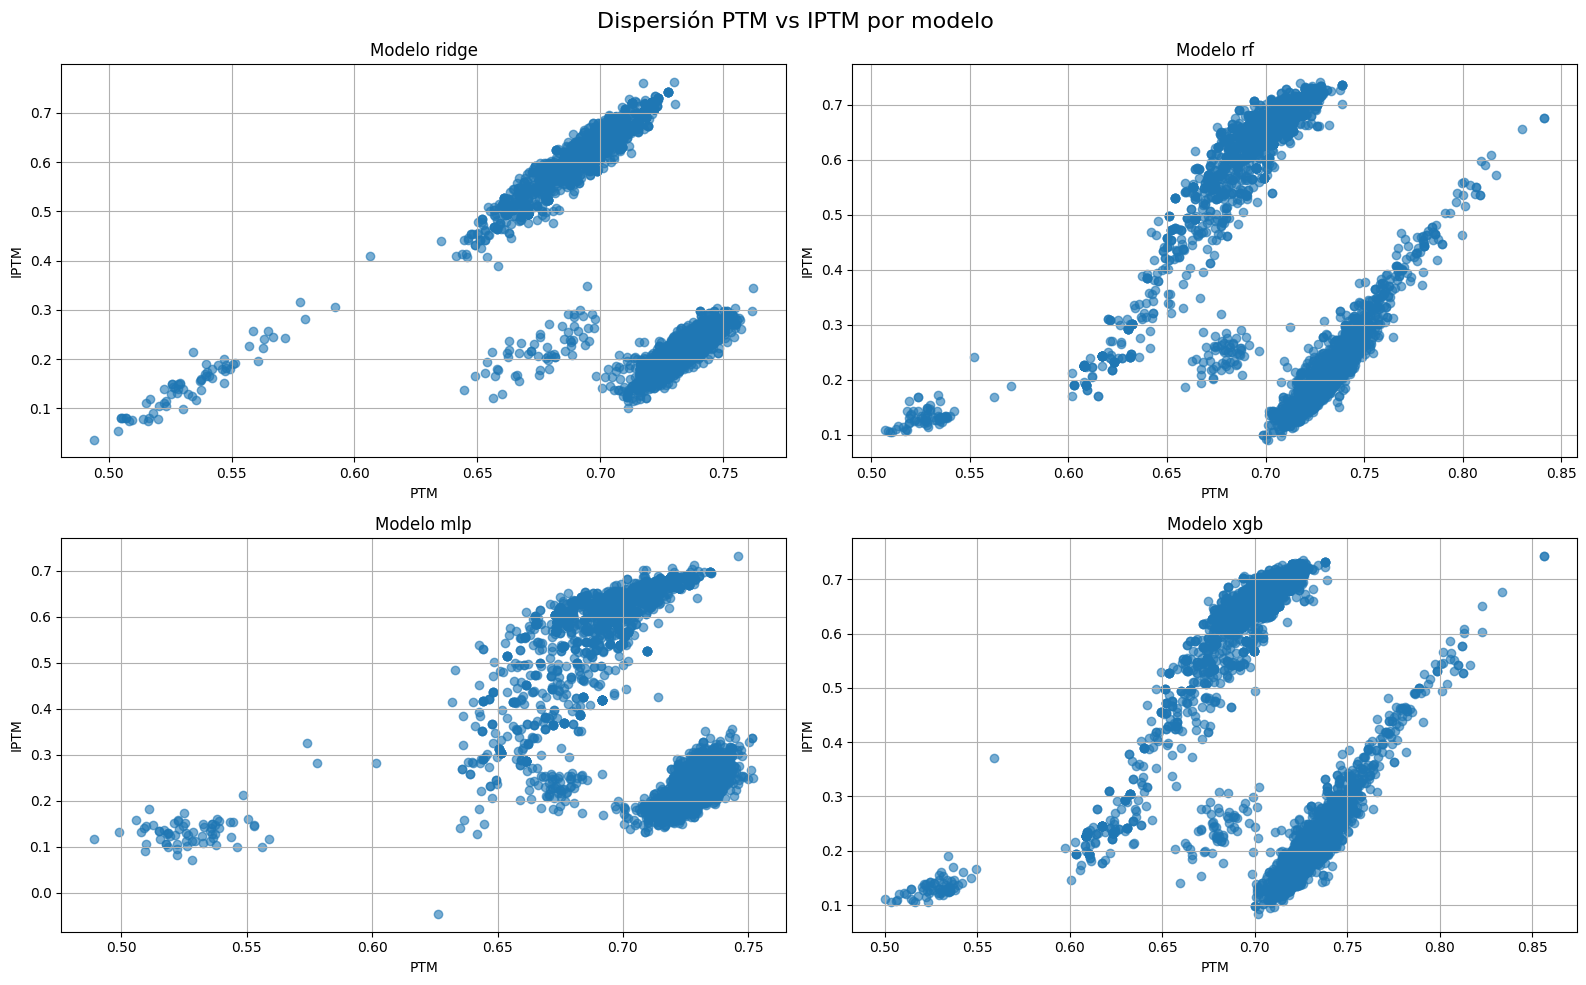

In [13]:
#Diagrama de dispersion sn riltros
import pandas as pd
import matplotlib.pyplot as plt

# Cargar datos
df = pd.read_csv("../outputs/predictions_all_models.csv")

models = ["ridge","rf","mlp","xgb"]

plt.figure(figsize=(16,10))

for i, model in enumerate(models,1):

    plt.subplot(2,2,i)

    ptm = df[f"{model}_PTM"]
    iptm = df[f"{model}_IPTM"]

    plt.scatter(
        ptm,
        iptm,
        alpha=0.6
    )

    plt.xlabel("PTM")
    plt.ylabel("IPTM")
    plt.title(f"Modelo {model}")
    plt.grid(True)

plt.suptitle("Dispersión PTM vs IPTM por modelo",fontsize=16)

plt.tight_layout()
plt.show()

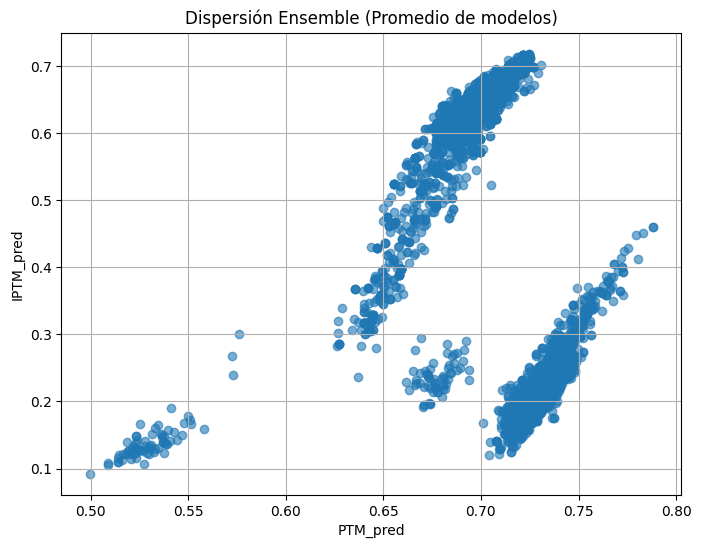

In [14]:
#Diagrama con el promedio de todos los modelos (ensemble)
plt.figure(figsize=(8,6))

plt.scatter(
    df["PTM_pred"],
    df["IPTM_pred"],
    alpha=0.6
)

plt.xlabel("PTM_pred")
plt.ylabel("IPTM_pred")
plt.title("Dispersión Ensemble (Promedio de modelos)")
plt.grid(True)

plt.show()

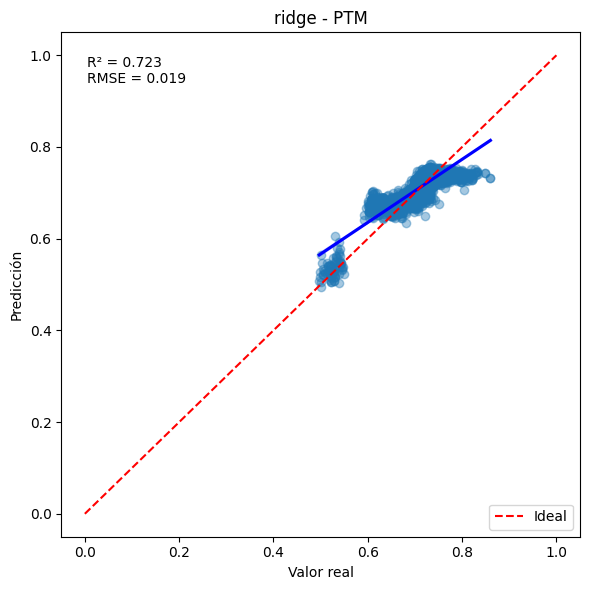

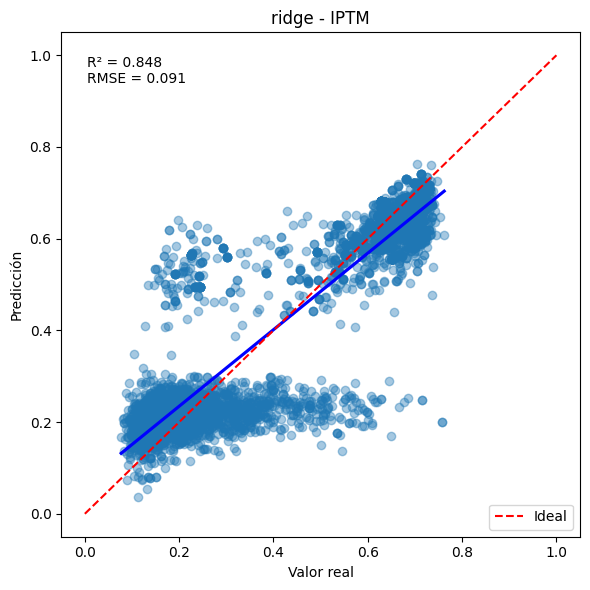

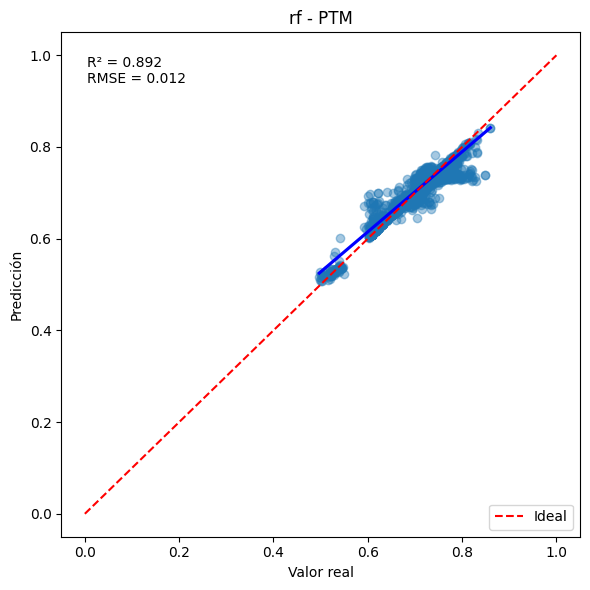

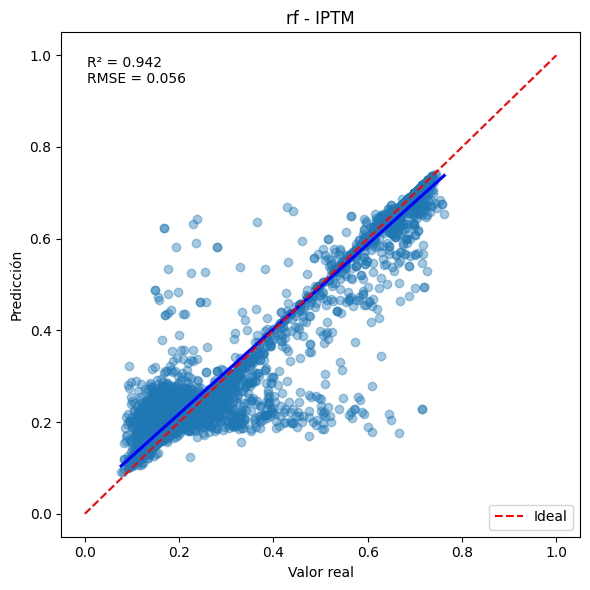

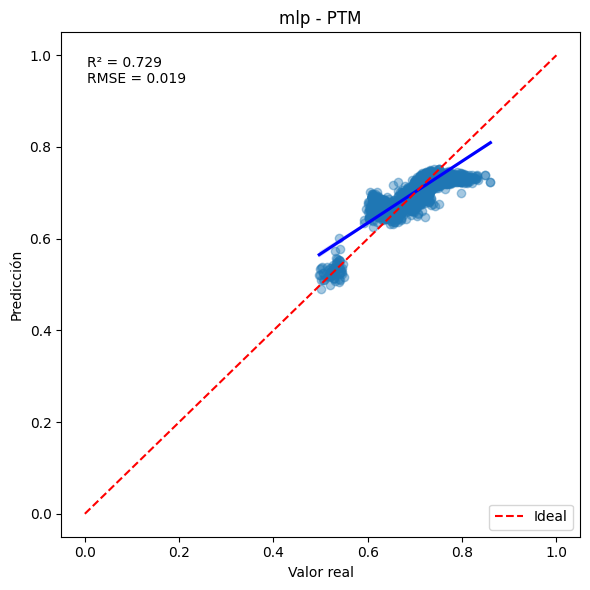

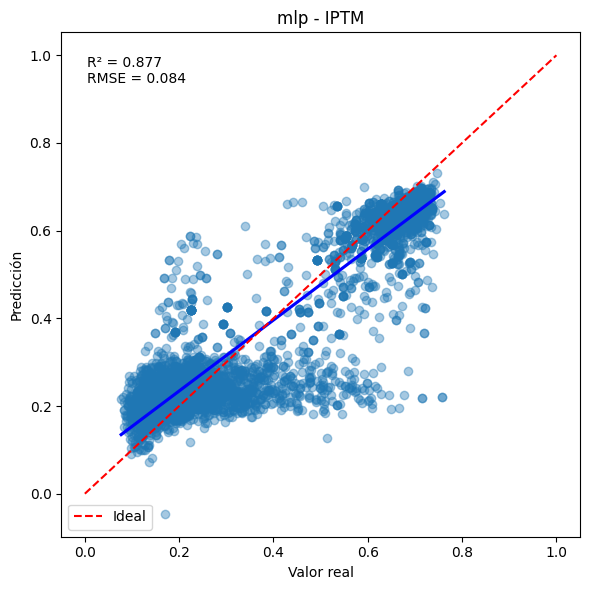

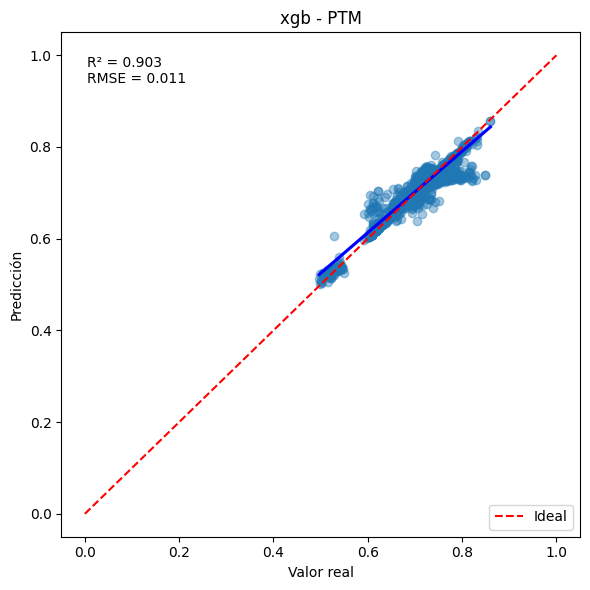

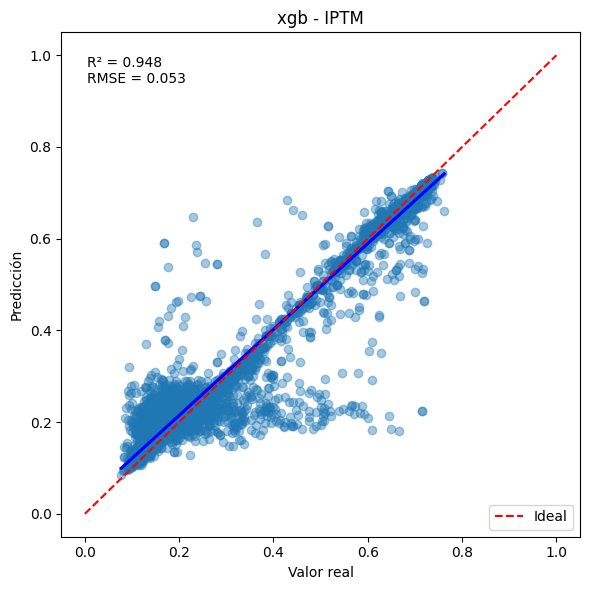

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# cargar datos
df_pred = pd.read_csv("../outputs/predictions_all_models.csv")
y_test = np.load("../outputs/y_test.npy")

# separar targets reales
df_pred["PTM_real"] = y_test[:,0]
df_pred["IPTM_real"] = y_test[:,1]

models = ["ridge","rf","mlp","xgb"]
targets = ["PTM","IPTM"]

for model in models:

    for target in targets:

        pred_col = f"{model}_{target}"
        real_col = f"{target}_real"

        if pred_col not in df_pred.columns:
            continue

        y_true = df_pred[real_col]
        y_pred = df_pred[pred_col]

        # métricas
        r2 = np.corrcoef(y_true,y_pred)[0,1]**2
        rmse = np.sqrt(np.mean((y_true-y_pred)**2))

        plt.figure(figsize=(6,6))

        sns.regplot(
            x=y_true,
            y=y_pred,
            scatter_kws={"alpha":0.4},
            line_kws={"color":"blue"}
        )

        # línea ideal
        plt.plot([0,1],[0,1],'r--',label="Ideal")

        plt.xlabel("Valor real")
        plt.ylabel("Predicción")
        plt.title(f"{model} - {target}")

        plt.text(
            0.05,0.9,
            f"R² = {r2:.3f}\nRMSE = {rmse:.3f}",
            transform=plt.gca().transAxes
        )

        plt.legend()

        plt.tight_layout()

        plt.show()

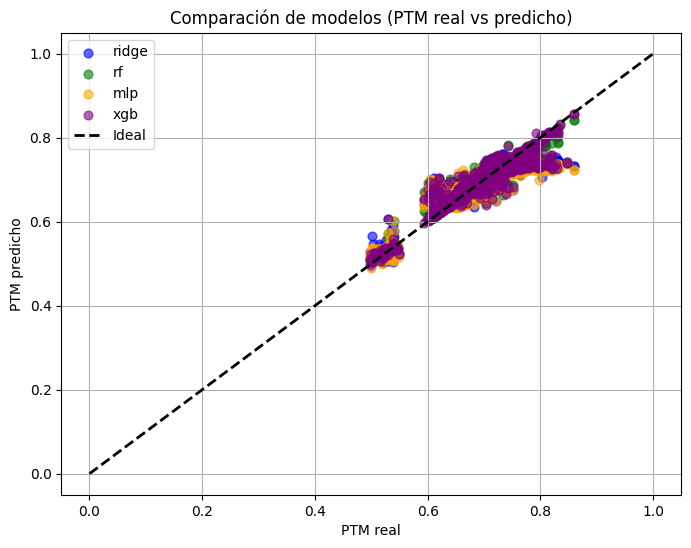

In [17]:
import matplotlib.pyplot as plt

# colores diferenciados
colors = {
    "ridge": "blue",
    "rf": "green",
    "mlp": "orange",
    "xgb": "purple"
}

plt.figure(figsize=(8,6))

for model in models:

    plt.scatter(
        df_pred["PTM_real"],
        df_pred[f"{model}_PTM"],
        alpha=0.6,
        color=colors[model],
        label=model,
        s=40
    )

# línea ideal
plt.plot([0,1],[0,1],'k--', linewidth=2, label="Ideal")

plt.xlabel("PTM real")
plt.ylabel("PTM predicho")

plt.title("Comparación de modelos (PTM real vs predicho)")

plt.legend()
plt.grid(True)

plt.show()